# 04. So sánh tất cả các mô hình và chọn Top 3

Notebook này ghép tất cả các kết quả từ:
1. **linear_models**: LinearRegression, Ridge, SVR, KNeighbors, MLP, v.v.
2. **tree_models**: DecisionTree, RandomForest, GradientBoosting, XGBoost
3. **ensemble_try1**: VotingRegressor và các model thành phần

Sau đó vẽ chart so sánh và chọn top 2-3 model tốt nhất.

## 1. Chuẩn bị thư viện và Cấu hình

In [42]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Setup paths
PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'research' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load results từ linear models

In [43]:
# Load linear models results
linear_df = pd.read_csv(METRICS_DIR / 'linear_models_results.csv')
print(f"Linear models: {len(linear_df)} records")
print(f"Columns: {linear_df.columns.tolist()}")
display(linear_df.head())

Linear models: 7 records
Columns: ['group_name', 'model_name', 'dataset_variant', 'cv_rmse', 'cv_mae', 'cv_rse', 'test_rmse', 'test_mae', 'test_rse', 'test_r2', 'cv_time_sec', 'fit_time_sec', 'rank_in_group']


,group_name,model_name,dataset_variant,cv_rmse,cv_mae,cv_rse,test_rmse,test_mae,test_rse,test_r2,cv_time_sec,fit_time_sec,rank_in_group
0,linear_models,MLPRegressor,robust_log_scaled,2.173823,1.499122,0.450625,2.109222,1.503208,0.438110,0.561890,11.946210,1.980370,1
1,linear_models,RidgeRegression,robust_log_scaled,2.188713,1.566469,0.456819,2.166889,1.557175,0.462394,0.537606,0.015884,0.001218,2
2,linear_models,SVR,robust_log_scaled,2.197660,1.490488,0.460561,2.174461,1.495234,0.465632,0.534368,1.730022,0.312752,3
3,linear_models,LinearSVR,robust_log_scaled,2.243512,1.543189,0.479980,2.175788,1.517793,0.466200,0.533800,0.046817,0.008457,4
4,linear_models,LinearRegression,robust_log_scaled,2.184263,1.568446,0.454963,2.177008,1.559670,0.466723,0.533277,0.140559,0.003510,5


## 3. Load results từ tree models

In [44]:
# Load tree models results
tree_df = pd.read_csv(METRICS_DIR / 'tree_baseline_results.csv')
print(f"Tree models: {len(tree_df)} records")
print(f"Columns: {tree_df.columns.tolist()}")
display(tree_df.head())

Tree models: 4 records
Columns: ['mse', 'rmse', 'rse', 'mae', 'Model', 'Train_Time']


,mse,rmse,rse,mae,Model,Train_Time
0,8.816587,2.969274,0.868239,2.052632,Decision_Tree,0.023938
1,4.827886,2.197245,0.475440,1.545199,Random_Forest,0.260065
2,4.757438,2.181155,0.468503,1.542060,Gradient_Boosting,0.649337
3,5.514435,2.348283,0.543050,1.659860,XGBoost,0.478976


## 4. Load results từ ensemble try1

In [45]:
# Load ensemble results
ensemble_df = pd.read_csv(METRICS_DIR / '04_model_ensemble_try1_comparison.csv')
print(f"Ensemble models: {len(ensemble_df)} records")
print(f"Columns: {ensemble_df.columns.tolist()}")
display(ensemble_df.head())

Ensemble models: 6 records
Columns: ['mo_hinh', 'MAE', 'RMSE', 'R2']


,mo_hinh,MAE,RMSE,R2
0,voting_ensemble,1.549685,2.192640,0.520809
1,ridge,1.620732,2.224273,0.506883
2,linear_regression,1.621848,2.228053,0.505206
3,gradient_boosting,1.590471,2.248320,0.496163
4,random_forest,1.594844,2.269166,0.486777


## 5. Chuẩn hóa tên cột và ghép lại

In [46]:
# Standardize linear results
linear_standardized = linear_df[['model_name', 'group_name', 'dataset_variant', 'test_rmse', 'test_mae', 'test_rse', 'test_r2']].copy()
linear_standardized.columns = ['model_name', 'group_name', 'dataset_variant', 'rmse', 'mae', 'rse', 'r2']
linear_standardized['model_group'] = 'linear_models'

# Standardize tree results - use correct lowercase column names
tree_standardized = tree_df[['Model', 'rmse', 'mae', 'rse']].copy()
tree_standardized.columns = ['model_name', 'rmse', 'mae', 'rse']
tree_standardized['group_name'] = 'tree_models'
tree_standardized['dataset_variant'] = 'standard_scaled'
tree_standardized['model_group'] = 'tree_models'
tree_standardized['r2'] = np.nan  # R2 not available in tree results

# Standardize ensemble results
# Columns: mo_hinh, MAE, RMSE, R2
ensemble_standardized = ensemble_df[['mo_hinh', 'RMSE', 'MAE', 'R2']].copy()
ensemble_standardized.columns = ['model_name', 'rmse', 'mae', 'r2']
ensemble_standardized['group_name'] = 'ensemble_try1'
ensemble_standardized['dataset_variant'] = 'mixed'
ensemble_standardized['model_group'] = 'ensemble'
ensemble_standardized['rse'] = np.nan  # RSE not available

# Combine all results
combined_df = pd.concat([
    linear_standardized[['model_name', 'group_name', 'dataset_variant', 'model_group', 'rmse', 'mae', 'rse', 'r2']],
    tree_standardized[['model_name', 'group_name', 'dataset_variant', 'model_group', 'rmse', 'mae', 'rse', 'r2']],
    ensemble_standardized[['model_name', 'group_name', 'dataset_variant', 'model_group', 'rmse', 'mae', 'rse', 'r2']]
], ignore_index=True)

# Sort by RMSE
combined_df = combined_df.sort_values('rmse', ascending=True).reset_index(drop=True)
combined_df['rank'] = range(1, len(combined_df) + 1)

print(f"Total models: {len(combined_df)}")
display(combined_df)

Total models: 17


,model_name,group_name,dataset_variant,model_group,rmse,mae,rse,r2,rank
0,MLPRegressor,linear_models,robust_log_scaled,linear_models,2.109222,1.503208,0.438110,0.561890,1
1,RidgeRegression,linear_models,robust_log_scaled,linear_models,2.166889,1.557175,0.462394,0.537606,2
2,SVR,linear_models,robust_log_scaled,linear_models,2.174461,1.495234,0.465632,0.534368,3
3,LinearSVR,linear_models,robust_log_scaled,linear_models,2.175788,1.517793,0.466200,0.533800,4
4,LinearRegression,linear_models,robust_log_scaled,linear_models,2.177008,1.559670,0.466723,0.533277,5
5,SGDRegressor,linear_models,robust_log_scaled,linear_models,2.177165,1.582212,0.466790,0.533210,6
6,Gradient_Boosting,tree_models,standard_scaled,tree_models,2.181155,1.542060,0.468503,NaN,7
7,voting_ensemble,ensemble_try1,mixed,ensemble,2.192640,1.549685,NaN,0.520809,8
8,Random_Forest,tree_models,standard_scaled,tree_models,2.197245,1.545199,0.475440,NaN,9
9,ridge,ensemble_try1,mixed,ensemble,2.224273,1.620732,NaN,0.506883,10


## 6. Hiển thị top 10 models theo RMSE

In [47]:
top_10 = combined_df.head(10)[['rank', 'model_name', 'group_name', 'rmse', 'mae', 'r2']]
print("\n=== TOP 10 MODELS THEO RMSE ===")
display(top_10)


=== TOP 10 MODELS THEO RMSE ===


,rank,model_name,group_name,rmse,mae,r2
0,1,MLPRegressor,linear_models,2.109222,1.503208,0.561890
1,2,RidgeRegression,linear_models,2.166889,1.557175,0.537606
2,3,SVR,linear_models,2.174461,1.495234,0.534368
3,4,LinearSVR,linear_models,2.175788,1.517793,0.533800
4,5,LinearRegression,linear_models,2.177008,1.559670,0.533277
5,6,SGDRegressor,linear_models,2.177165,1.582212,0.533210
6,7,Gradient_Boosting,tree_models,2.181155,1.542060,NaN
7,8,voting_ensemble,ensemble_try1,2.192640,1.549685,0.520809
8,9,Random_Forest,tree_models,2.197245,1.545199,NaN
9,10,ridge,ensemble_try1,2.224273,1.620732,0.506883


## 7. Trực quan hóa so sánh các metrics

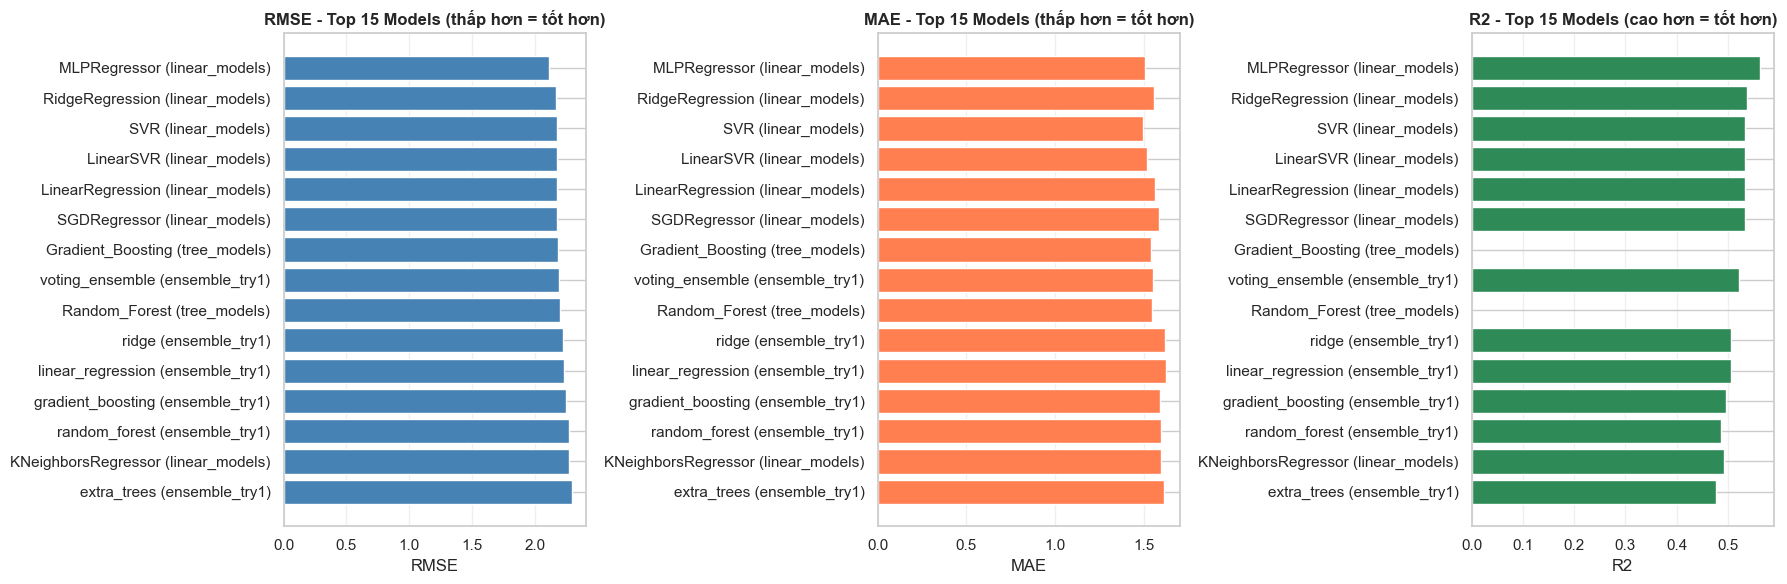

Saved: 04_model_compare_metrics.png


In [48]:
# Prepare data for visualization - top 15 models
viz_df = combined_df.head(15).copy()
viz_df['model_display'] = viz_df['model_name'] + ' (' + viz_df['group_name'] + ')'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE comparison
axes[0].barh(viz_df['model_display'], viz_df['rmse'], color='steelblue')
axes[0].set_title('RMSE - Top 15 Models (thấp hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1].barh(viz_df['model_display'], viz_df['mae'], color='coral')
axes[1].set_title('MAE - Top 15 Models (thấp hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('MAE')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# R2 comparison
axes[2].barh(viz_df['model_display'], viz_df['r2'], color='seagreen')
axes[2].set_title('R2 - Top 15 Models (cao hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('R2')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_model_compare_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 04_model_compare_metrics.png')

## 8. Biểu đồ so sánh (MAE vs RMSE)

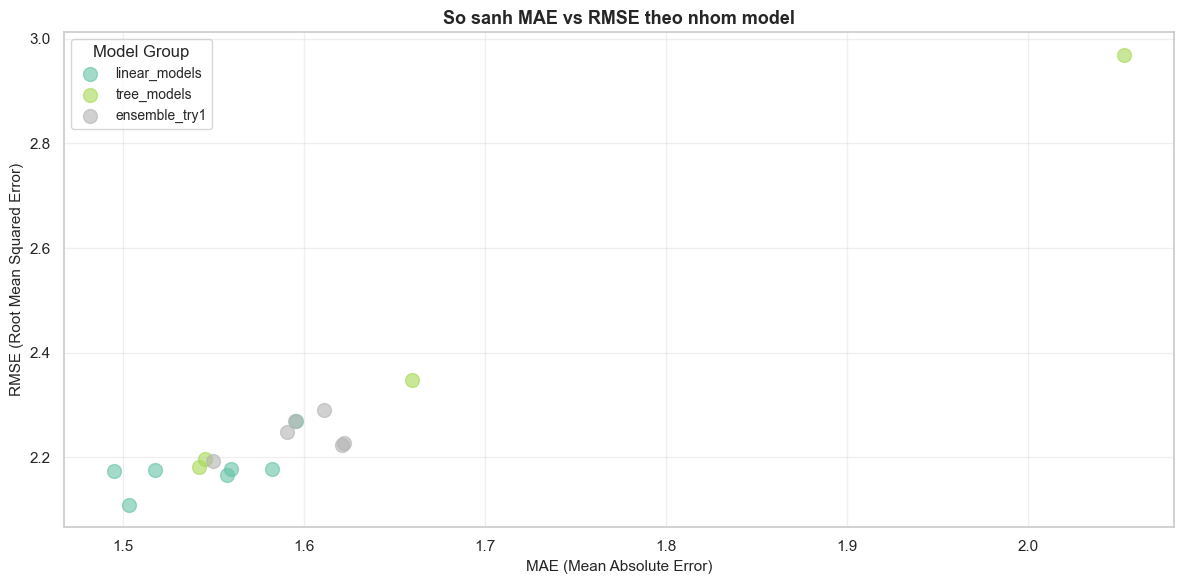

Saved: 04_model_compare_scatter.png


In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create scatter plot colored by group
groups = combined_df['group_name'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(groups)))
group_color_map = dict(zip(groups, colors))

for group in groups:
    group_data = combined_df[combined_df['group_name'] == group]
    ax.scatter(group_data['mae'], group_data['rmse'], 
              label=group, s=100, alpha=0.6,
              color=group_color_map[group])

ax.set_xlabel('MAE (Mean Absolute Error)', fontsize=11)
ax.set_ylabel('RMSE (Root Mean Squared Error)', fontsize=11)
ax.set_title('So sanh MAE vs RMSE theo nhom model', fontsize=13, fontweight='bold')
ax.legend(title='Model Group', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_model_compare_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 04_model_compare_scatter.png')

## 9. Phân tích đặc điểm của top models

In [50]:
# Analyze top 3 models
top_3 = combined_df.head(3)

print("\n" + "="*70)
print("TOP 3 MODELS DUOC CHI DINH")
print("="*70)

for idx, row in top_3.iterrows():
    rank = row['rank']
    model = row['model_name']
    group = row['group_name']
    rmse = row['rmse']
    mae = row['mae']
    r2 = row['r2']
    
    print(f"\n#{rank}: {model}")
    print(f"   Group: {group}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R2:   {r2:.4f}")


TOP 3 MODELS DUOC CHI DINH

#1: MLPRegressor
   Group: linear_models
   RMSE: 2.1092
   MAE:  1.5032
   R2:   0.5619

#2: RidgeRegression
   Group: linear_models
   RMSE: 2.1669
   MAE:  1.5572
   R2:   0.5376

#3: SVR
   Group: linear_models
   RMSE: 2.1745
   MAE:  1.4952
   R2:   0.5344


## 10. Thống kê theo nhóm model

In [ ]:
# Create ranking by group
group_stats = combined_df.groupby('group_name').agg({
    'rmse': ['min', 'mean', 'max'],
    'mae': ['min', 'mean', 'max'],
    'r2': ['max', 'mean', 'min'],
    'model_name': 'count'
}).round(4)

print("\n=== THỐNG KÊ THEO NHÓM ===")
display(group_stats)


=== THONG KE THEO NHOM ===


rmse                     mae                      r2          \
                  min    mean     max     min    mean     max     max    mean   
group_name                                                                      
ensemble_try1  2.1926  2.2421  2.2900  1.5497  1.5981  1.6218  0.5208  0.4989   
linear_models  2.1092  2.1786  2.2698  1.4952  1.5444  1.5954  0.5619  0.5324   
tree_models    2.1812  2.4240  2.9693  1.5421  1.6999  2.0526     NaN     NaN   

                      model_name  
                  min      count  
group_name                        
ensemble_try1  0.4773          6  
linear_models  0.4926          7  
tree_models       NaN          4

## 11. Biểu đồ so sánh mô hình tốt nhất của mỗi nhóm

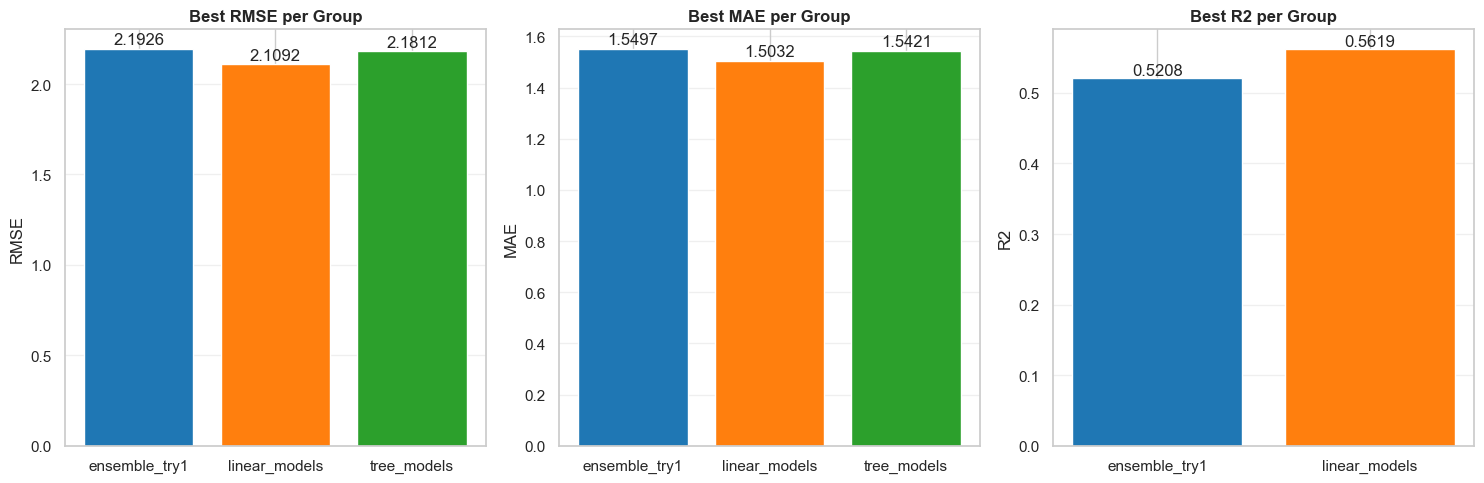

Saved: 04_model_compare_best_per_group.png


In [52]:
# Best model per group
best_per_group = combined_df.loc[combined_df.groupby('group_name')['rmse'].idxmin()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Best RMSE per group
axes[0].bar(best_per_group['group_name'], best_per_group['rmse'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Best RMSE per Group', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(best_per_group['rmse']):
    if np.isfinite(v):  # Only add text if value is valid
        axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# Best MAE per group
axes[1].bar(best_per_group['group_name'], best_per_group['mae'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Best MAE per Group', fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(best_per_group['mae']):
    if np.isfinite(v):  # Only add text if value is valid
        axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# Best R2 per group
axes[2].bar(best_per_group['group_name'], best_per_group['r2'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_title('Best R2 per Group', fontweight='bold')
axes[2].set_ylabel('R2')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(best_per_group['r2']):
    if np.isfinite(v):  # Only add text if value is valid
        axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_model_compare_best_per_group.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 04_model_compare_best_per_group.png')

## 12. Lưu kết quả

In [53]:
# Save combined results
combined_df.to_csv(METRICS_DIR / 'model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')

# Save top 3 summary
top_3_summary = combined_df.head(3)[['rank', 'model_name', 'group_name', 'rmse', 'mae', 'r2']].to_dict(orient='records')
with open(METRICS_DIR / 'top_3_models.json', 'w', encoding='utf-8') as f:
    json.dump(top_3_summary, f, ensure_ascii=False, indent=2)
print('Saved: top_3_models.json')

Saved: model_comparison_results.csv
Saved: top_3_models.json
